# Analysis for instagram account

# Instagram Data Analysis

This project aims to analyze Instagram post performance using a dataset that includes metrics such as Likes, Reach, Impressions, and sources of traffic (From Home, From Hashtags, From Explore, From Other).  

The goal is to understand which traffic sources contribute the most to post reach and engagement, and to explore potential relationships between content features (like caption length or hashtags) and audience response.

The analysis will include:
- Basic data cleaning and exploration  
- Summary statistics  
- Visualizations (pie charts, bar plots, scatter plots, regression lines, etc.)  
- Insights about performance trends  

This project is still in development — structure and methods may change as the analysis progresses.


## Project Overview

The project focuses on exploring how different factors affect post performance on Instagram.  
The dataset contains columns related to user engagement, reach, and traffic sources.  

The analysis will go through several main phases:

1. **Data Loading & Inspection**  
   Import the dataset, check for missing values, data types, and overall structure.

2. **Data Cleaning (if necessary)**  
   Handle null values, rename columns, and prepare the data for analysis.

3. **Exploratory Data Analysis (EDA)**  
   - Summarize key statistics  
   - Compare traffic sources (Home, Hashtags, Explore, Other)  
   - Identify which source brings the highest reach  
   - Explore relationships between Likes, Caption_Words, and Reach

4. **Visualization**  
   Use Matplotlib and Seaborn to create:
   - Pie charts showing reach distribution  
   - Bar charts for source comparisons  
   - Scatter and regression plots for relationships  

5. **Insights & Notes**  
   Highlight interesting findings, trends, or anomalies observed in the data.

This section provides a roadmap for the steps that will be developed throughout the notebook.


In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r"D:\abdo.work\Instagram data.csv" , encoding="latin1")

In [3]:
df.head(1)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...


In [4]:
df.shape

(119, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [6]:
df.duplicated().sum()

np.int64(17)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.isnull().sum()

Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [9]:
df.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits',
       'Follows', 'Caption', 'Hashtags'],
      dtype='object')

In [10]:
df.max()

Impressions                                                   36919
From Home                                                     13473
From Hashtags                                                 11817
From Explore                                                  17414
From Other                                                     2547
Saves                                                          1095
Comments                                                         19
Shares                                                           75
Likes                                                           549
Profile Visits                                                  611
Follows                                                         260
Caption           You must have seen the news divided into categ...
Hashtags          #timeseries #time #statistics #datascience #bi...
dtype: object

In [11]:
df.head(3)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...


In [12]:
caption = df["Caption"].str.split(" ").str.len()
df["Caption_Words"] = caption

In [13]:
df.head(3)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags,Caption_Words
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,16
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,34
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...,20


In [14]:
df["Hashtags_count"] = df["Hashtags"].str.replace("#"," ").str.split().str.len()

In [15]:
df.head(2)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags,Caption_Words,Hashtags_count
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,16,22
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,34,18


In [16]:
df["top_way"]= df[["From Home","From Hashtags","From Explore","From Explore"]].idxmax(axis=1)

In [17]:
df.head(2)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags,Caption_Words,Hashtags_count,top_way
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,16,22,From Home
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,34,18,From Home


In [18]:
import matplotlib.pyplot as plt

* top post 

In [19]:
df['Total_Engagement'] = df['Likes'] + df['Comments'] + df['Follows']
top_posts = df.sort_values(by='Total_Engagement', ascending=False).head(1)
top_posts[['Caption', 'Likes', 'Comments', 'Follows', 'Total_Engagement']]


,Caption,Likes,Comments,Follows,Total_Engagement
117,Here are some of the best data science certifi...,549,2,214,765


In [20]:
total_hashtags = df["From Hashtags"].sum(axis=0)
total_from_home = df["From Home"].sum(axis=0)
total_from_explore = df["From Explore"].sum(axis=0)
total_from_other = df["From Other"].sum(axis=0)
df_total = pd.Series ([total_hashtags,total_from_home,total_from_explore,total_from_other] , index=["From Hashtags","From Home","From Explore","From Other"])
df_total.reset_index()
df_total.columns = ["source" , "total"]
df_total

From Hashtags    200765
From Home        254685
From Explore     120214
From Other        18824
dtype: int64

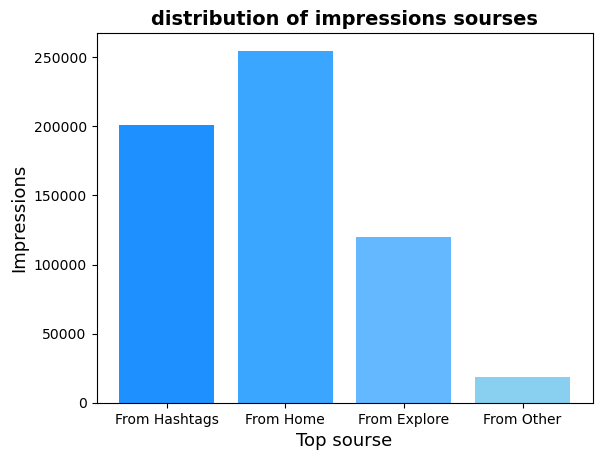

In [21]:
plt.bar(["From Hashtags","From Home","From Explore","From Other"],[total_hashtags,total_from_home,total_from_explore,total_from_other],color=['#1E90FF', '#3AA6FF', '#63B8FF', '#89CFF0'])
plt.xlabel("Top sourse",fontsize=13)
plt.ylabel("Impressions",fontsize=13)
plt.title("distribution of impressions sourses" , fontsize = 14 , fontweight = "bold")
plt.show()

In [22]:
import seaborn as sns

Text(0.5, 1.0, 'Relationship Between caption and likes')

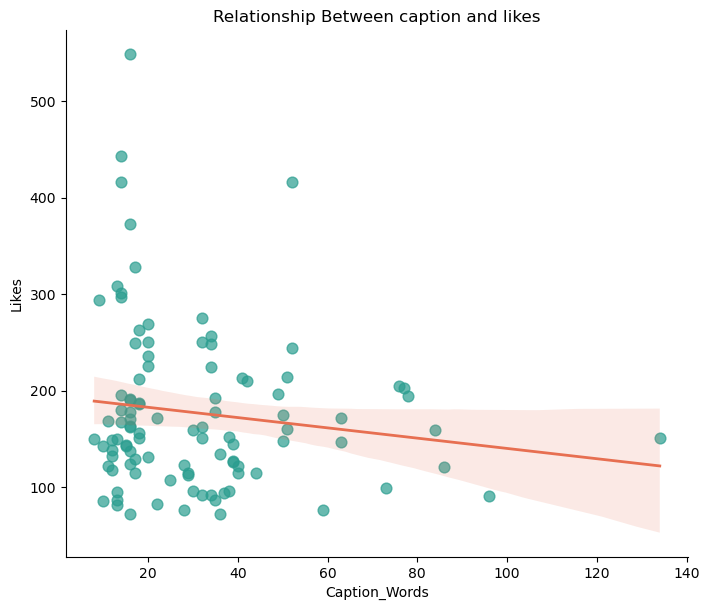

In [23]:
sns.lmplot(x="Caption_Words",y="Likes",data=df , height=6 ,aspect=1.2 ,scatter_kws={'s': 60, 'alpha': 0.7, 'color': '#2a9d8f'},
    line_kws={'color': '#e76f51', 'lw': 2}) 
plt.title("Relationship Between caption and likes")

Text(0.5, 1.0, 'Relationship Between from explore and likes')

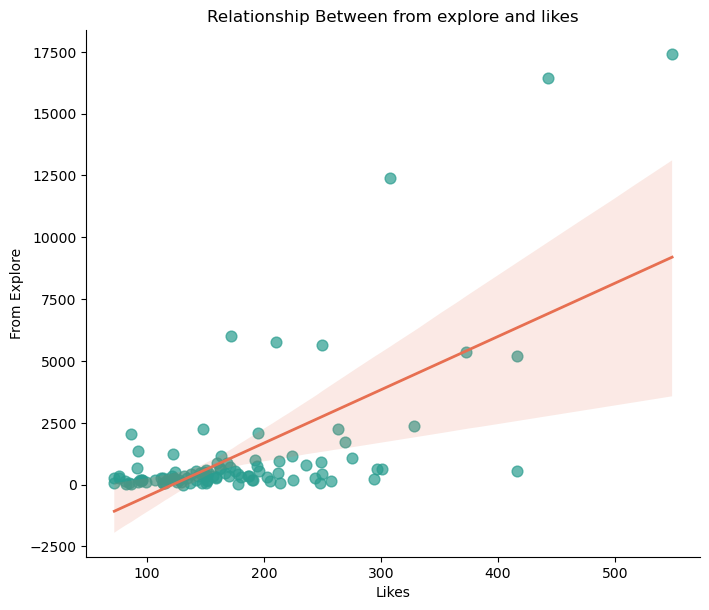

In [24]:
sns.lmplot(x="Likes",y="From Explore",data=df , height=6 ,aspect=1.2 ,scatter_kws={'s': 60, 'alpha': 0.7, 'color': '#2a9d8f'},
    line_kws={'color': '#e76f51', 'lw': 2}) 
plt.title("Relationship Between from explore and likes")

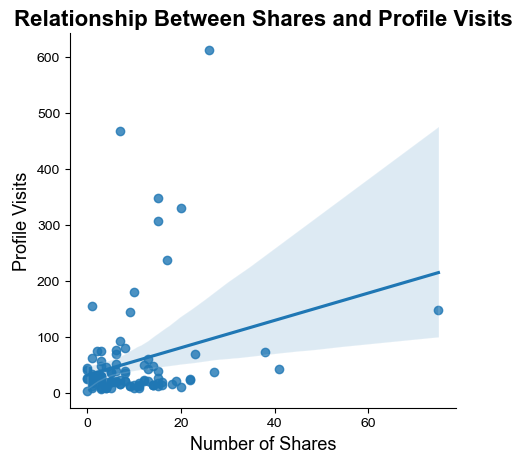

In [25]:
sns.lmplot(x="Shares",y="Profile Visits",data=df)
sns.set_style("whitegrid")
sns.set_context("talk")
plt.title("Relationship Between Shares and Profile Visits", fontsize=16, fontweight='bold')
plt.xlabel("Number of Shares", fontsize=13)
plt.ylabel("Profile Visits", fontsize=13)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Relationship between profile visits and follows ')

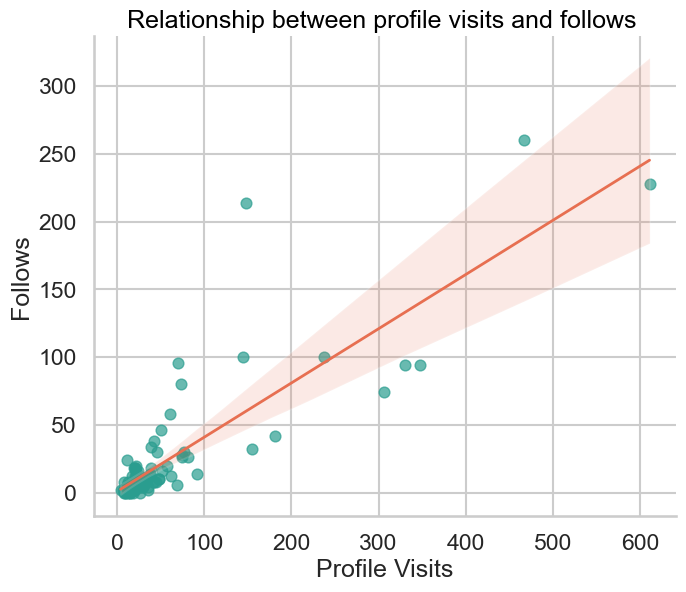

In [26]:
sns.lmplot(x="Profile Visits",y="Follows",data=df , height=6 ,aspect=1.2 ,scatter_kws={'s': 60, 'alpha': 0.7, 'color': '#2a9d8f'},
    line_kws={'color': '#e76f51', 'lw': 2}) 
plt.title("Relationship between profile visits and follows ",color = "black") 

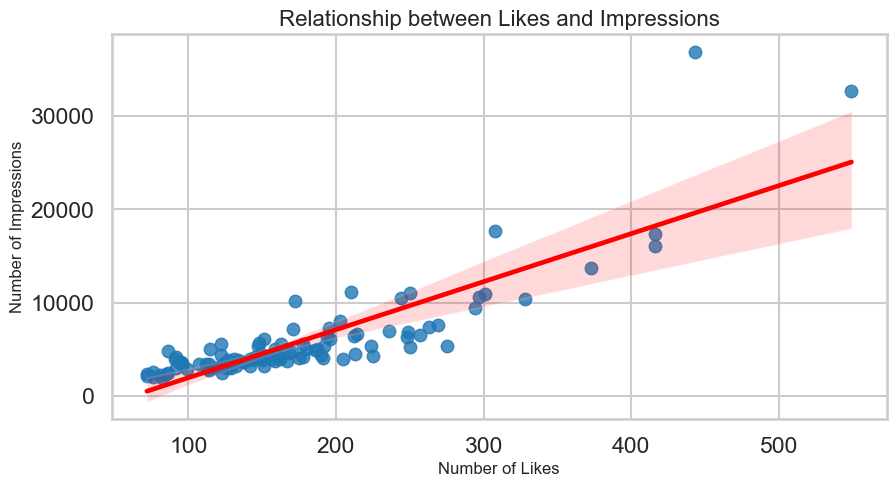

In [27]:
plt.figure(figsize=(10,5))
sns.regplot(x='Likes', y='Impressions', data=df, line_kws={'color':'red'})


plt.title('Relationship between Likes and Impressions', fontsize=16)
plt.xlabel('Number of Likes', fontsize=12)
plt.ylabel('Number of Impressions', fontsize=12)
plt.grid(True)
plt.show()

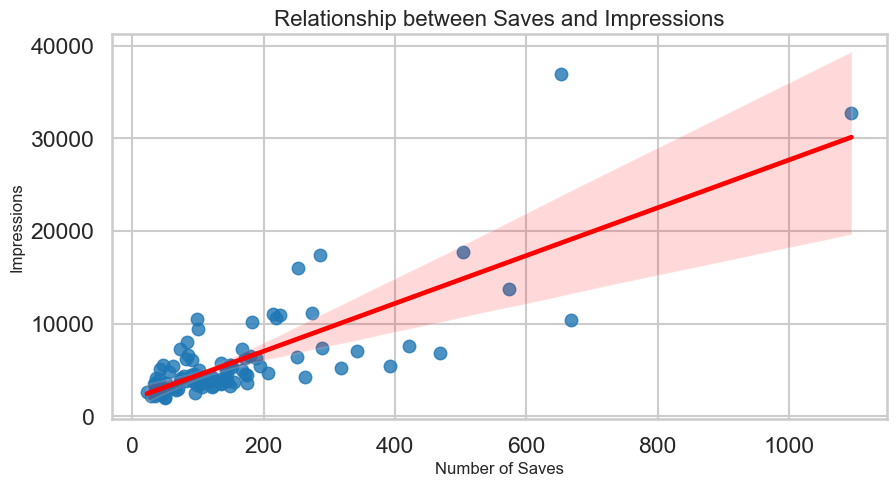

In [28]:
plt.figure(figsize=(10,5))
sns.regplot(x='Saves', y='Impressions', data=df, line_kws={'color':'red'})


plt.title('Relationship between Saves and Impressions', fontsize=16)
plt.xlabel('Number of Saves', fontsize=12)
plt.ylabel('Impressions', fontsize=12)
plt.grid(True)
plt.show()

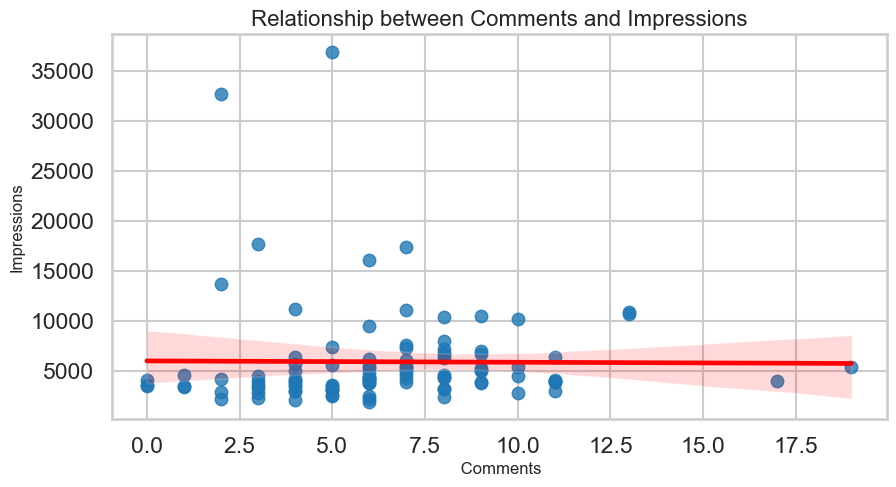

In [29]:
plt.figure(figsize=(10,5))
sns.regplot(x='Comments', y='Impressions', data=df, line_kws={'color':'red'})


plt.title('Relationship between Comments and Impressions', fontsize=16)
plt.xlabel(' Comments', fontsize=12)
plt.ylabel('Impressions', fontsize=12)
plt.grid(True)
plt.show()

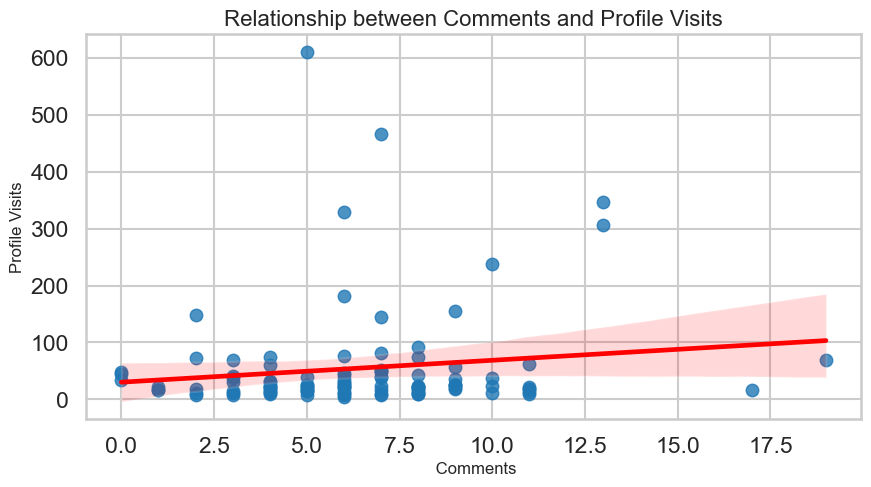

In [30]:
plt.figure(figsize=(10,5))
sns.regplot(x='Comments', y='Profile Visits', data=df, line_kws={'color':'red'})


plt.title('Relationship between Comments and Profile Visits', fontsize=16)
plt.xlabel(' Comments', fontsize=12)
plt.ylabel('Profile Visits', fontsize=12)
plt.grid(True)
plt.show()

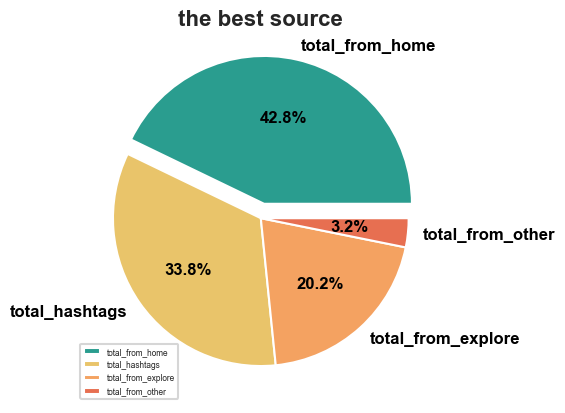

In [31]:
pie2 = ([total_from_home,total_hashtags,total_from_explore,total_from_other])
plt.pie(pie2,labels=["total_from_home","total_hashtags","total_from_explore","total_from_other"],
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'black'},
        colors = ["#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"],explode=[.1,0,0,0],autopct="%1.1f%%"
)
plt.title("the best source",fontsize=16,fontweight="bold")
plt.legend(fontsize=6)
plt.show()



# ........................................................................................................................................................
# ........................................................................................................................................................

## 📊 Insights & Analysis

### 🔹 General Overview
After cleaning and processing the dataset, the analysis revealed key patterns in how different engagement metrics (likes, comments, saves, follows) influence impressions and profile visits.  
Most impressions were generated mainly from **Home** and **Explore**, while **Hashtags** and **Other** contributed less significantly.

---

### 🔹 Captions & Engagement
- Posts with **longer captions** (more caption words) tended to receive **slightly more likes**.  
  This suggests that descriptive or expressive captions help improve user interaction.  
- Although the correlation is not very strong, the trend indicates that good caption writing can positively impact engagement.

---

### 🔹 Explore & Visibility
- A **positive relationship** was observed between **Likes** and **From Explore** impressions.  
  Posts reaching the Explore page gained **higher visibility and likes**, confirming Explore’s importance for organic growth.  
- The **bar chart** of impression sources also showed that **Home** and **Explore** dominate total impressions, making them the key drivers of post reach.

---

### 🔹 Shares, Profile Visits & Follows
- The regression plot between **Shares** and **Profile Visits** showed that as shares increase, more users visit the profile.  
  Shared posts are more likely to attract new visitors.  
- A strong positive correlation was found between **Profile Visits** and **Follows**, meaning that driving traffic to the profile directly supports follower growth.

---

### 🔹 Engagement & Impressions
- **Likes, Comments, and Saves** all showed a **positive correlation** with **Impressions**.  
  Posts that trigger user actions (like saving or commenting) tend to reach more people.  
- This confirms that **interaction boosts reach**, and the Instagram algorithm favors posts that keep users engaged.

---

### 🔹 Top-Performing Post
- The top-performing post — based on **Total Engagement (Likes + Comments + Follows)** — had the highest visibility and overall performance.  
  This post serves as a strong reference for understanding what type of content resonates best with the audience.

---

### 🔹 Overall Summary
- Engagement directly drives visibility and growth.  
- **Home** and **Explore** remain the most effective sources for impressions.  
- Well-written captions, shareable content, and user interaction (likes, comments, save


In [32]:
df.head(5)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags,Caption_Words,Hashtags_count,top_way,Total_Engagement
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,16,22,From Home,173
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,34,18,From Home,241
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...,20,18,From Home,154
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...,41,11,From Home,231
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...,28,29,From Home,128
